In [ ]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr 
import matplotlib.patches as mpatches
import rioxarray as rioxr
import contextily as ctx


In [34]:
eaton_fp = 'data/Eaton_Perimeter_20250121.geojson'
palisades_fp = 'data/Palisades_Perimeter_20250121.geojson'

eaton = gpd.read_file(eaton_fp)
palisades = gpd.read_file(palisades_fp)

In [35]:
eji_data = gpd.read_file(os.path.join('data', 'EJI_2024_United_States.gdb'))

eji_data

,OBJECTID,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,...,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag,Shape_Length,Shape_Area,geometry
0,835,01,089,003100,140000US01089003100,01089003100,01089003100,Madison County,Alabama,AL,...,381.0,7.1,0.0,0.0,0.0,-999,-999,8510.888655,4.333530e+06,"MULTIPOLYGON (((852482.839 -266767.398, 853314..."
1,928,01,095,031200,140000US01095031200,01095031200,01095031200,Marshall County,Alabama,AL,...,276.0,4.7,0.0,0.0,0.0,-999,-999,22311.962049,2.907722e+07,"MULTIPOLYGON (((896720.330 -319662.354, 896744..."
2,605,01,073,012401,140000US01073012401,01073012401,01073012401,Jefferson County,Alabama,AL,...,152.0,4.2,0.0,0.0,0.0,-999,-999,10719.250036,4.753795e+06,"MULTIPOLYGON (((837006.682 -399280.247, 837159..."
3,500,01,073,003400,140000US01073003400,01073003400,01073003400,Jefferson County,Alabama,AL,...,51.0,2.7,0.0,0.0,0.0,-999,-999,6199.992414,2.044441e+06,"MULTIPOLYGON (((837411.783 -407460.771, 837500..."
4,540,01,073,010402,140000US01073010402,01073010402,01073010402,Jefferson County,Alabama,AL,...,22.0,0.8,0.0,0.0,0.0,-999,-999,7419.649259,2.403345e+06,"MULTIPOLYGON (((831455.566 -422273.151, 832285..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85180,85171,78,010,971200,140000US78010971200,78010971200,78010971200,St. Croix Island,United States Virgin Islands,VI,...,-999.0,-999.0,-999.0,-999.0,0.0,-999,-999,13334.672970,6.251142e+06,"MULTIPOLYGON (((3376821.625 -1619294.010, 3377..."
85181,85185,78,030,960900,140000US78030960900,78030960900,78030960900,St. Thomas Island,United States Virgin Islands,VI,...,-999.0,-999.0,-999.0,-999.0,0.0,-999,-999,27507.640374,8.175590e+06,"MULTIPOLYGON (((3357342.662 -1556347.913, 3357..."
85182,85174,78,010,971500,140000US78010971500,78010971500,78010971500,St. Croix Island,United States Virgin Islands,VI,...,-999.0,-999.0,-999.0,-999.0,0.0,-999,-999,9439.126938,4.531441e+06,"MULTIPOLYGON (((3386421.950 -1611349.951, 3386..."
85183,85173,78,010,971400,140000US78010971400,78010971400,78010971400,St. Croix Island,United States Virgin Islands,VI,...,-999.0,-999.0,-999.0,-999.0,0.0,-999,-999,33579.027069,2.286307e+07,"MULTIPOLYGON (((3389638.925 -1616116.052, 3389..."


In [38]:
eji_data.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [39]:
eji_data = eji_data.to_crs(palisades.crs)

In [40]:
assert (eaton.crs == eji_data.crs)

<Axes: >

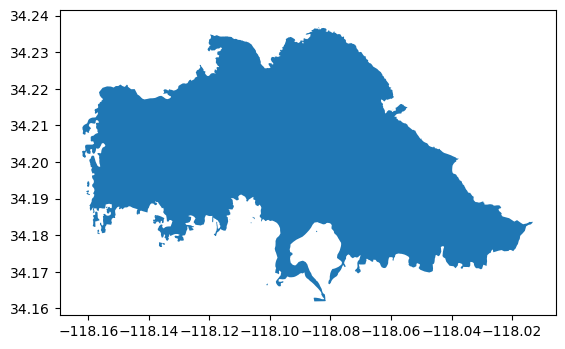

In [41]:
eaton.plot()

<Axes: >

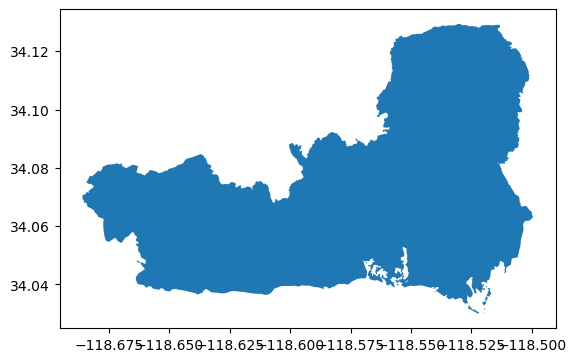

In [42]:
palisades.plot()

<Axes: >

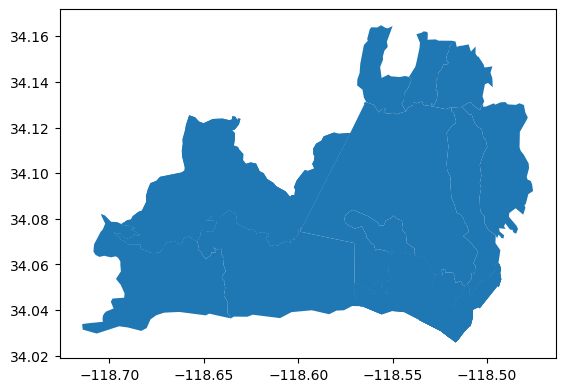

In [9]:
eji_palisades = gpd.sjoin(eji_data, palisades, predicate = 'intersects')

eji_palisades.plot()

<Axes: >

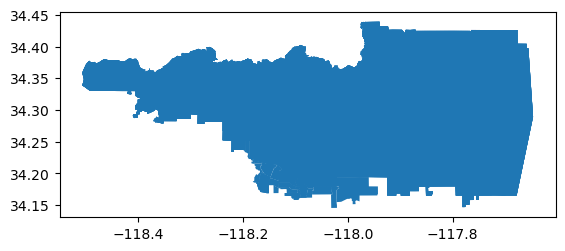

In [43]:
eji_eaton = gpd.sjoin(eji_data, eaton, predicate = 'intersects')
# sjoin(eji, eaton, how = 'inner')
eji_eaton.plot()

<Axes: >

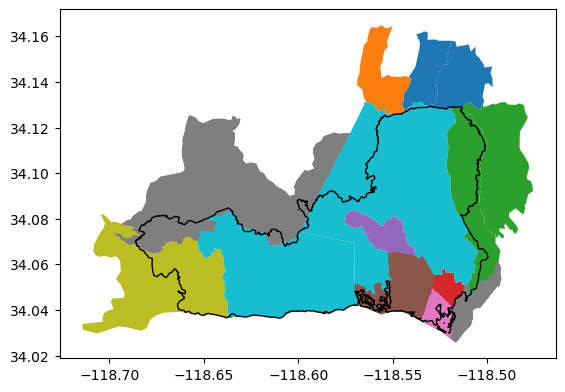

In [45]:
fig, ax = plt.subplots()

eji_palisades.plot(ax = ax,
                  column = 'TRACTCE')

palisades.plot(ax = ax,
              color = 'none')

<Axes: >

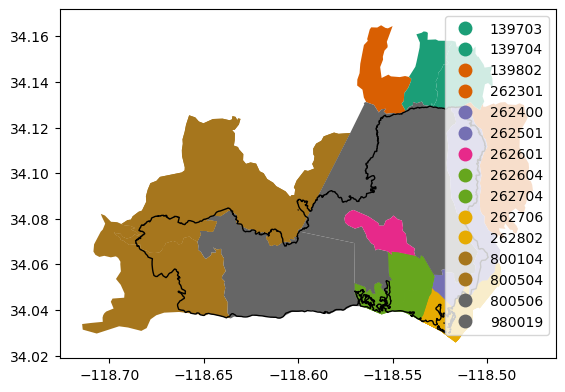

In [44]:
fig, ax = plt.subplots()

eji_palisades.plot(ax = ax,
                  column = 'TRACTCE',
                  cmap = 'Dark2',
                  legend = True)

palisades.plot(ax = ax,
              color = 'none')

<Axes: >

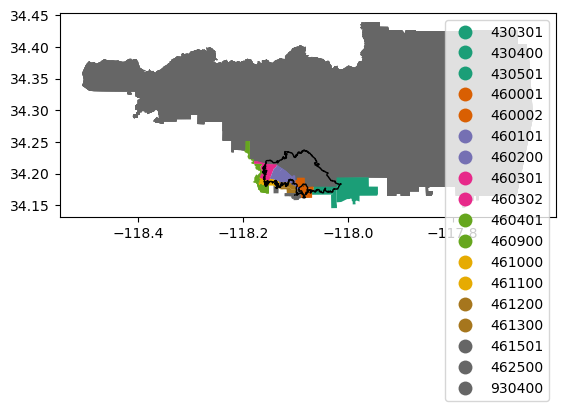

In [13]:
fig, ax = plt.subplots()

eji_eaton.plot(ax = ax,
                  column = 'TRACTCE',
                  cmap = 'Dark2',
                  legend = True)

eaton.plot(ax = ax,
              color = 'none')

## 3. Polygon clipping

In [46]:
palisades_clip = gpd.clip(eji_data, palisades)
eaton_clip = gpd.clip(eji_data, eaton)

<Axes: >

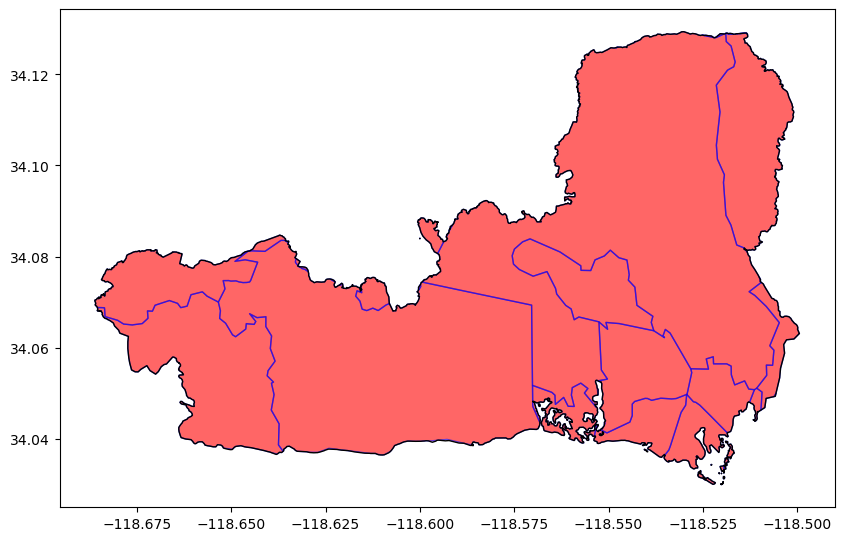

In [48]:
# plot palisades clip
fig, ax = plt.subplots (figsize = (10,8))
palisades_clip.plot(ax = ax, facecolor = 'red', edgecolor = 'blue', alpha = .6)
palisades.plot(ax = ax,
              color = 'none')

In [ ]:
eaton_clip

<Axes: >

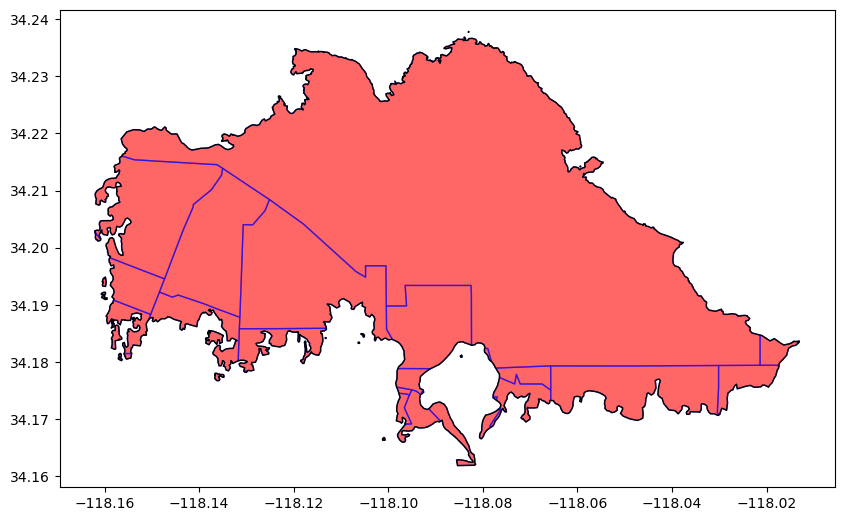

In [50]:
# plot eaton clip
fig, ax = plt.subplots (figsize = (10,8))
eaton_clip.plot(ax = ax, facecolor = 'red', edgecolor = 'blue', alpha = .6)
eaton.plot(ax = ax,
              color = 'none')


## Visualize fire perimeters with a basemap
To add a basemap to our plot we will be using the contextily library.

Import the contextily library at the top of your notebook as ctx. This library is already installed in the EDS 220 environment.

Use and update the code below to plot the fire perimeters adding a basemap:

/opt/anaconda3/envs/eds220-env/lib/python3.11/site-packages/contextily/tile.py:645: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


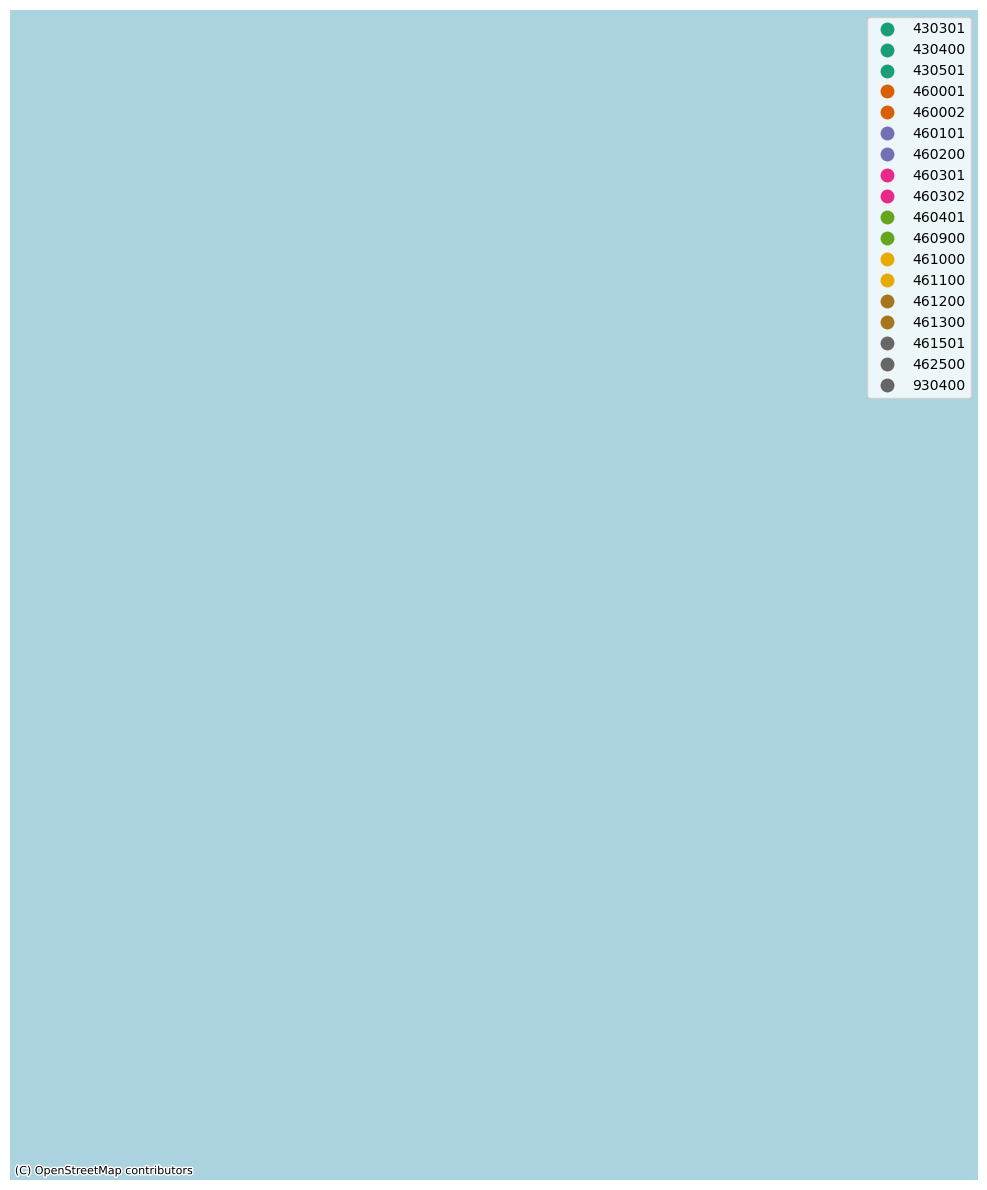

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Add basemap using contextily
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# ADD FIRE PERIMETERS: UPDATE FILL TRANSPARENCY AND COLOR
eji_eaton.plot(ax = ax,
                  column = 'TRACTCE',
                  cmap = 'Dark2',
                  legend = True)

palisades.plot(ax = ax,
              color = 'none')

eaton.plot(ax = ax,
              color = 'none')
# ADD LEGEND OR ANNOTATION TO IDENTIFY EACH FIRE

# ADD TITLE

ax.axis('off')

plt.tight_layout()
plt.show()

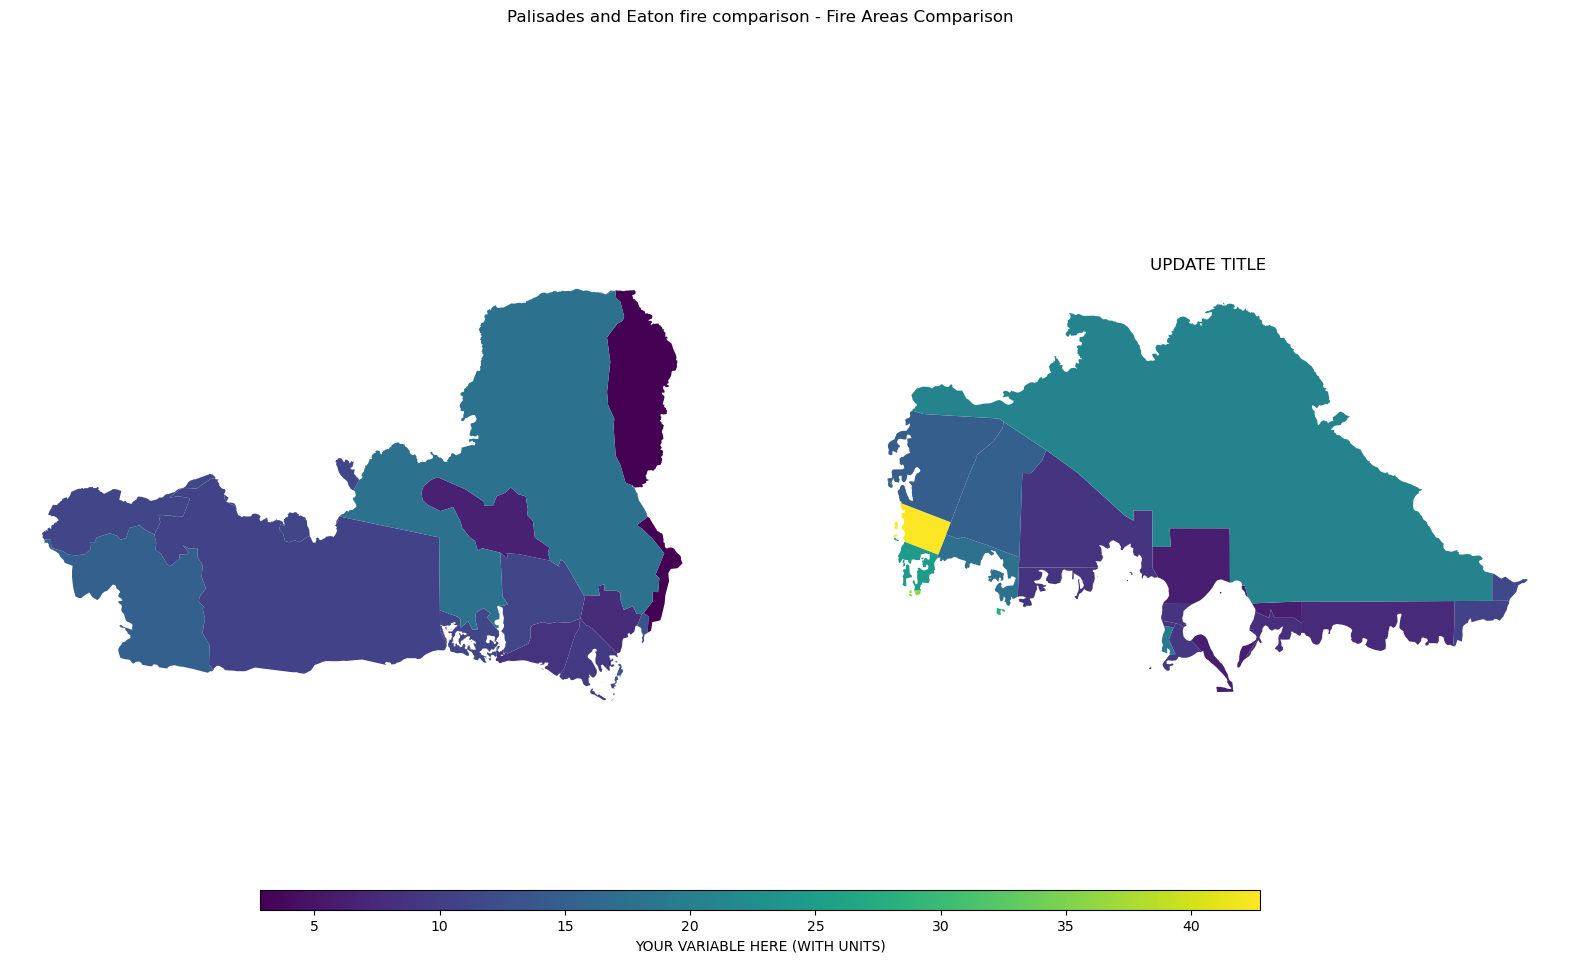

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
# UPDATE WITH YOU EJI VARIABLE FROM STEP 1
eji_variable = 'E_POV200'
census_within_palisades = palisades_clip
census_within_eaton = eaton_clip
# Find common min/max for legend range
vmin = min(census_within_palisades[eji_variable].min(), census_within_eaton[eji_variable].min())
vmax = max(census_within_palisades[eji_variable].max(), census_within_eaton[eji_variable].max())
# Plot census tracts within Palisades perimeter
census_within_palisades.plot(
    column= eji_variable,
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax1,
)
ax1.set_title('Palisades Fire Overlay')
ax1.axis('off')
# Plot census tracts within Eaton perimeter
census_within_eaton.plot(
    column=eji_variable,
    vmin=vmin, vmax=vmax,
    legend=False,
    ax=ax2,
)
ax2.set_title('Eaton Fire Overlay')
ax2.axis('off')
# Add overall title
fig.suptitle('Palisades and Eaton Fire Comparison - Fire Areas Comparison')
# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable( norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('% Residents Below 200% Poverty Line')
plt.show()